RQ2: Can introducing semantically valid, artificially crafted, and maliciously altered network flow perturbations, creating the effects of a network evasion attack, into an IDS testing dataset, such as the Unified Multimodal NIDS CIC-IDS2019 dataset, reduce the robustness of an existing pre-trained model? 

H20: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model’s testing dataset has no statistically significant effect on the model's overall performance.

H2a: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model’s testing dataset has a statistically significant effect on the model's overall performance.

In [1]:
import matplotlib.pyplot as plt
import json
import numpy as np
import os
import pandas as pd
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from xgboost import XGBClassifier

In [2]:
N_BOOT = 5000
N_EVAL = 30000
RNG = np.random.default_rng(42)

In [3]:
df = pd.read_csv('data/clean_sample_150000.csv')
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])
X = df.drop(columns=['label', 'flowid'], errors='ignore').select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df['label']

In [4]:
def base_xgb(): return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.03, eval_metric="mlogloss", random_state=42, tree_method="hist")

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_test_arr = y_test.reset_index(drop=True).to_numpy()

In [6]:
def load_adv(path):
    d = pd.read_csv(path)
    drop = [c for c in ['true_label', 'pred_clean', 'pred_adv', 'y_pred', 'confidence'] if c in d.columns]
    Xa = d.drop(columns=drop, errors='ignore').select_dtypes(include=[np.number])
    Xa.replace([np.inf, -np.inf], np.nan, inplace=True)
    Xa.fillna(0, inplace=True)
    Xa = Xa.reindex(columns=X_train.columns, fill_value=0).astype('float32')
    ya = d['true_label'].values.astype(int)
    return Xa.values, ya

In [7]:
def strat_sample(Xe, ye, n=N_EVAL):
    idx = np.concatenate([RNG.choice(np.where(ye == c)[0], size=n // 3, replace=False) for c in [0, 1, 2]])
    return Xe[idx], ye[idx]

In [8]:
def boot_ci(vals, q_lo=2.5, q_hi=97.5):
    return round(np.percentile(vals, q_lo), 4), round(np.percentile(vals, q_hi), 4)

In [9]:
model = base_xgb()
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


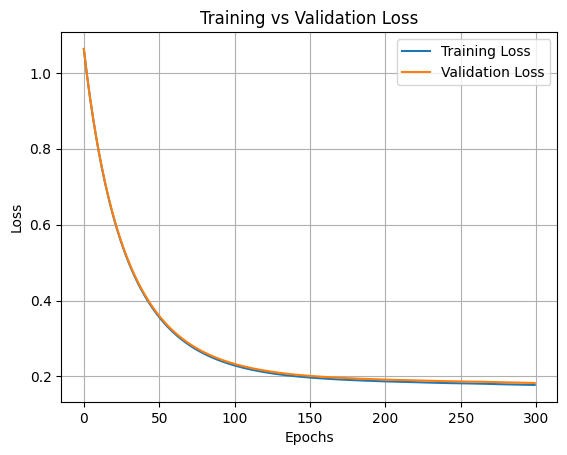

In [10]:
results = model.evals_result()

train_loss = results['validation_0']['mlogloss']
val_loss   = results['validation_1']['mlogloss']

plt.figure()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [11]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.9070666666666667
Weighted F1: 0.9069017276411161
Macro F1: 0.9069017276411162
ROC-AUC: 0.9828945200000001


In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     10000
    DoS_ATTACK       0.89      0.82      0.85     10000
NON_DoS_ATTACK       0.83      0.90      0.87     10000

      accuracy                           0.91     30000
     macro avg       0.91      0.91      0.91     30000
  weighted avg       0.91      0.91      0.91     30000



In [13]:
def benign_fpr(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    benign = y_true == 0
    return float((y_pred[benign] != 0).mean()) if benign.any() else 0.0

In [14]:
def macro_pr(y_true, y_pred, K=3):          # macro precision, macro recall via confusion matrix
    cm = np.bincount(y_true*K + y_pred, minlength=K*K).reshape(K, K).astype(float)
    d = np.diag(cm); col = cm.sum(0); row = cm.sum(1)
    prec = np.where(col > 0, d/col, 0).mean()
    rec  = np.where(row > 0, d/row, 0).mean()
    return float(prec), float(rec)

In [15]:
EPSILONS = [
    ('Control (clean)', None),
    ('Epsilon = 0.01',  'data/adversarial_full_epsilon_0.01.csv'),
    ('Epsilon = 0.05',  'data/adversarial_full_epsilon_0.05.csv'),
    ('Epsilon = 0.10',  'data/adversarial_full_epsilon_0.1.csv'),
    ('Epsilon = 0.50',  'data/adversarial_full_epsilon_0.5.csv')]

In [16]:
M_ALPHA = 0.05 / 12
def ci(a, alpha=0.05): return (round(float(np.percentile(a, 100*alpha/2)), 4),
                               round(float(np.percentile(a, 100*(1-alpha/2))), 4))
res = {}
for name, path in EPSILONS:
    if path is None: Xe, ye = X_test.values, y_test_arr
    else:            Xe, ye = strat_sample(*load_adv(path))
    yp = model.predict(Xe)
    P, R = macro_pr(ye, yp); F = benign_fpr(ye, yp)
    B = np.array([ (lambda i: (*macro_pr(ye[i], yp[i]), benign_fpr(ye[i], yp[i])))(
                     RNG.integers(0, len(ye), len(ye)) ) for _ in range(N_BOOT) ])
    res[name] = dict(ye=ye, yp=yp, prec=P, rec=R, fpr=F,
                     prec_ci=ci(B[:,0]), rec_ci=ci(B[:,1]), fpr_ci=ci(B[:,2]))
    print(f"{name:<18} P={P:.4f}{res[name]['prec_ci']}  R={R:.4f}{res[name]['rec_ci']}  FPR={F:.4f}{res[name]['fpr_ci']}")

ctrl = res['Control (clean)']; reject_any = False
for name, path in EPSILONS[1:]:
    r = res[name]; dP, dR, dF = (np.empty(N_BOOT) for _ in range(3))
    for b in range(N_BOOT):
        ic = RNG.integers(0, len(ctrl['ye']), len(ctrl['ye'])); ie = RNG.integers(0, len(r['ye']), len(r['ye']))
        cP, cR = macro_pr(ctrl['ye'][ic], ctrl['yp'][ic]); cF = benign_fpr(ctrl['ye'][ic], ctrl['yp'][ic])
        eP, eR = macro_pr(r['ye'][ie],   r['yp'][ie]);     eF = benign_fpr(r['ye'][ie],   r['yp'][ie])
        dP[b], dR[b], dF[b] = cP-eP, cR-eR, eF-cF          # degradation-positive
    for lbl, dd in [('precision', dP), ('recall', dR), ('FPR', dF)]:
        lo, hi = np.percentile(dd, 100*M_ALPHA/2), np.percentile(dd, 100*(1-M_ALPHA/2))
        sig = not (lo <= 0 <= hi); reject_any |= sig
        print(f"  {name} {lbl:<9} mean={dd.mean():+.4f} Bonf-CI[{lo:+.4f},{hi:+.4f}] {'SIG' if sig else 'ns'}")
print("H2:", "reject H2_0" if reject_any else "fail to reject H2_0")

Control (clean)    P=0.9087(0.9055, 0.9119)  R=0.9071(0.9038, 0.9102)  FPR=0.0000(0.0, 0.0)
Epsilon = 0.01     P=0.7537(0.7491, 0.7583)  R=0.7301(0.7257, 0.7345)  FPR=0.1749(0.1675, 0.1822)
Epsilon = 0.05     P=0.6470(0.6427, 0.6513)  R=0.5358(0.5312, 0.5406)  FPR=0.7016(0.6924, 0.7107)
Epsilon = 0.10     P=0.5891(0.5816, 0.5963)  R=0.4186(0.4141, 0.4233)  FPR=0.9487(0.9443, 0.953)
Epsilon = 0.50     P=0.1188(0.1025, 0.1359)  R=0.1486(0.1452, 0.152)  FPR=0.9981(0.9972, 0.9989)
  Epsilon = 0.01 precision mean=+0.1550 Bonf-CI[+0.1470,+0.1627] SIG
  Epsilon = 0.01 recall    mean=+0.1770 Bonf-CI[+0.1691,+0.1845] SIG
  Epsilon = 0.01 FPR       mean=+0.1750 Bonf-CI[+0.1643,+0.1856] SIG
  Epsilon = 0.05 precision mean=+0.2617 Bonf-CI[+0.2540,+0.2695] SIG
  Epsilon = 0.05 recall    mean=+0.3712 Bonf-CI[+0.3630,+0.3791] SIG
  Epsilon = 0.05 FPR       mean=+0.7016 Bonf-CI[+0.6884,+0.7141] SIG
  Epsilon = 0.10 precision mean=+0.3195 Bonf-CI[+0.3084,+0.3315] SIG
  Epsilon = 0.10 recall    mean=+0.

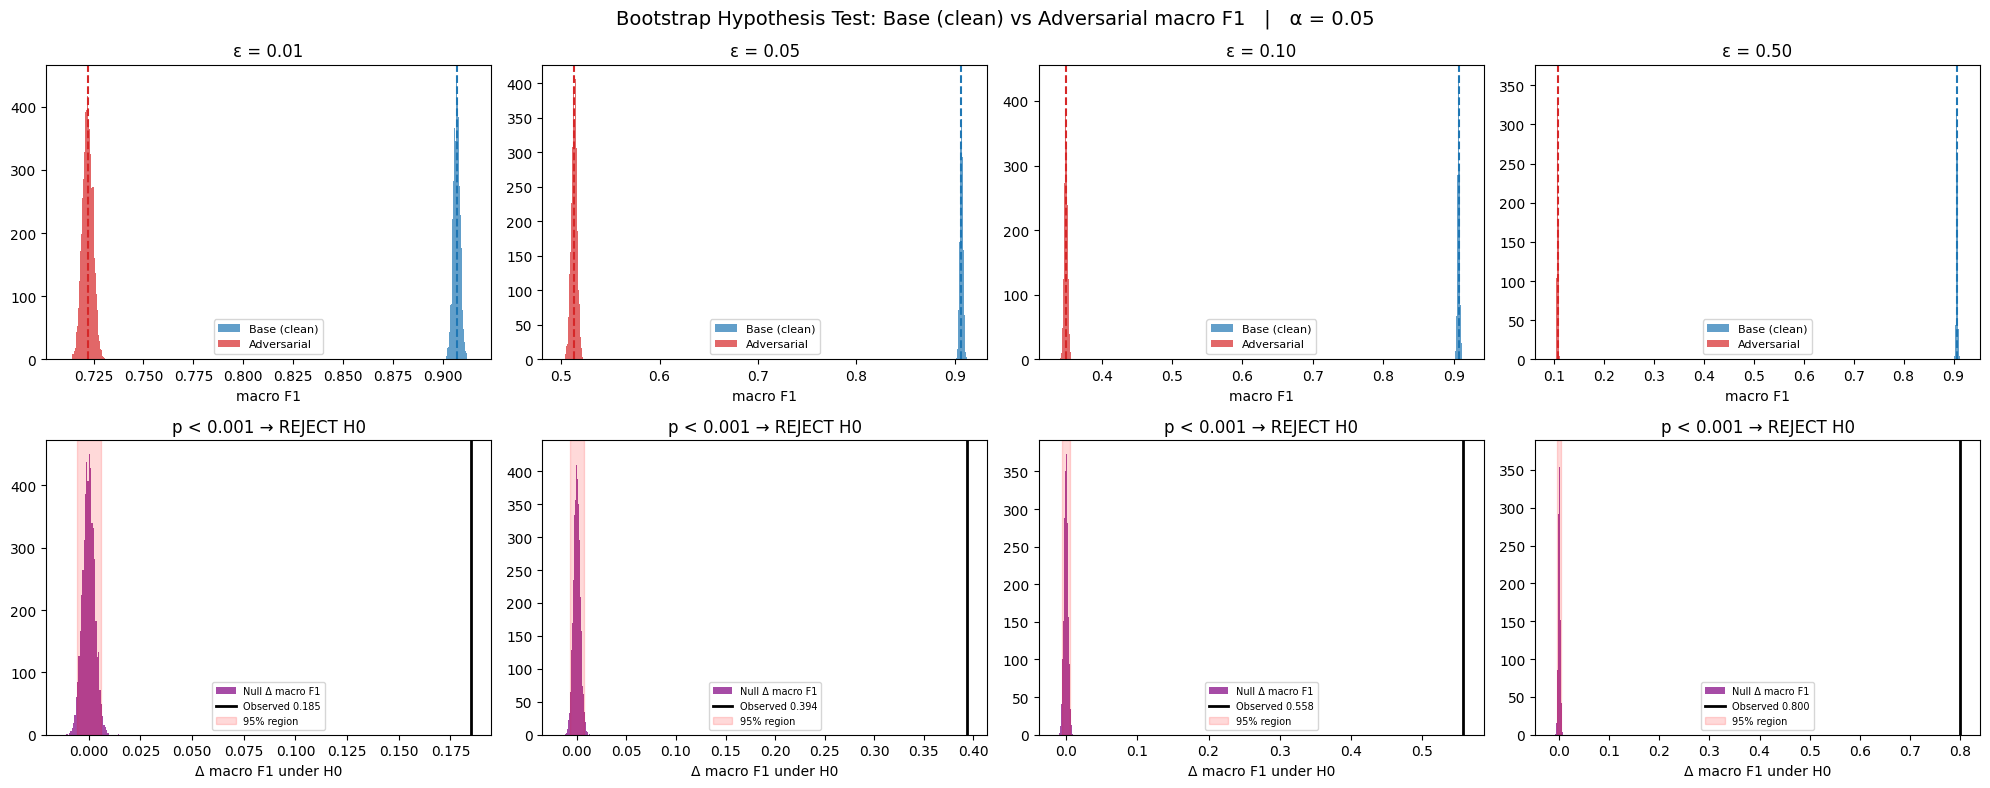

saved bootstrap_hypothesis_test.png — copy to DIS-9400/Images/


In [17]:
# Figure 32 — Bootstrap hypothesis test: base-model macro F1 on clean vs adversarial test sets (corrected data)
_fig_eps = [('ε = 0.01','data/adversarial_full_epsilon_0.01.csv'),('ε = 0.05','data/adversarial_full_epsilon_0.05.csv'),
            ('ε = 0.10','data/adversarial_full_epsilon_0.1.csv'),('ε = 0.50','data/adversarial_full_epsilon_0.5.csv')]
def _mf1(yt, yp):
    cm = np.bincount(yt*3 + yp, minlength=9).reshape(3,3).astype(float); d = np.diag(cm)
    den = 2*d + (cm.sum(0)-d) + (cm.sum(1)-d); return float(np.where(den>0, 2*d/den, 0).mean())
yc = model.predict(X_test.values)
fig, ax = plt.subplots(2, 4, figsize=(20, 8))
for j, (nm, path) in enumerate(_fig_eps):
    Xa, ya = strat_sample(*load_adv(path)); ypa = model.predict(Xa)
    cf = np.empty(N_BOOT); af = np.empty(N_BOOT)
    for b in range(N_BOOT):
        ic = RNG.integers(0, len(y_test_arr), len(y_test_arr)); ia = RNG.integers(0, len(ya), len(ya))
        cf[b] = _mf1(y_test_arr[ic], yc[ic]); af[b] = _mf1(ya[ia], ypa[ia])
    ax[0, j].hist(cf, bins=40, alpha=.7, label='Base (clean)'); ax[0, j].hist(af, bins=40, alpha=.7, color='tab:red', label='Adversarial')
    ax[0, j].axvline(cf.mean(), ls='--', color='tab:blue'); ax[0, j].axvline(af.mean(), ls='--', color='tab:red')
    ax[0, j].set_title(nm); ax[0, j].set_xlabel('macro F1'); ax[0, j].legend(fontsize=8)
    obs = _mf1(y_test_arr, yc) - _mf1(ya, ypa); null = (cf - af) - (cf - af).mean()
    lo, hi = np.percentile(null, 2.5), np.percentile(null, 97.5)
    pv = min(np.mean(null <= -abs(obs)), np.mean(null >= abs(obs))) * 2
    ax[1, j].hist(null, bins=40, alpha=.7, color='purple', label='Null Δ macro F1')
    ax[1, j].axvline(obs, color='k', lw=2, label=f'Observed {obs:.3f}'); ax[1, j].axvspan(lo, hi, alpha=.15, color='red', label='95% region')
    _pstr = 'p < 0.001' if pv < 0.001 else f'p = {pv:.3f}'
    ax[1, j].set_title(f'{_pstr} → REJECT H0' if pv < .05 else _pstr); ax[1, j].set_xlabel('Δ macro F1 under H0'); ax[1, j].legend(fontsize=7)
fig.suptitle('Bootstrap Hypothesis Test: Base (clean) vs Adversarial macro F1   |   α = 0.05', fontsize=14)
plt.tight_layout(); plt.savefig('bootstrap_hypothesis_test.png', dpi=120, bbox_inches='tight'); plt.show()
print('saved bootstrap_hypothesis_test.png — copy to DIS-9400/Images/')

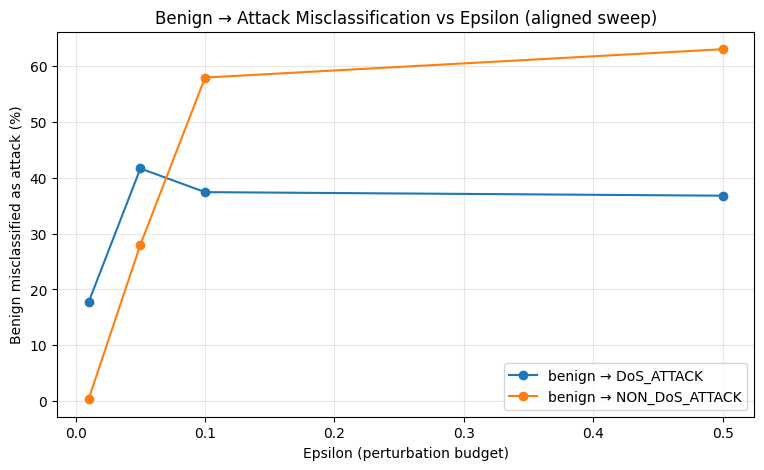

saved benign_targeted_asr.png — copy to DIS-9400/Images/; dos+nondos per eps = benign FPR


In [18]:
_eps_num = [0.01, 0.05, 0.10, 0.50]
_paths = {0.01:'data/adversarial_full_epsilon_0.01.csv', 0.05:'data/adversarial_full_epsilon_0.05.csv',
          0.10:'data/adversarial_full_epsilon_0.1.csv', 0.50:'data/adversarial_full_epsilon_0.5.csv'}
dos, nondos = [], []
for e in _eps_num:
    Xa, ya = load_adv(_paths[e]); mask = ya == 0
    pr = model.predict(Xa[mask])
    dos.append(100*np.mean(pr == 1)); nondos.append(100*np.mean(pr == 2))
plt.figure(figsize=(9, 5))
plt.plot(_eps_num, dos, 'o-', label='benign → DoS_ATTACK')
plt.plot(_eps_num, nondos, 'o-', label='benign → NON_DoS_ATTACK')
plt.xlabel('Epsilon (perturbation budget)'); plt.ylabel('Benign misclassified as attack (%)')
plt.title('Benign → Attack Misclassification vs Epsilon (aligned sweep)'); plt.legend(); plt.grid(True, alpha=.3)
plt.savefig('benign_targeted_asr.png', dpi=120, bbox_inches='tight'); plt.show()
print('saved benign_targeted_asr.png — copy to DIS-9400/Images/; dos+nondos per eps = benign FPR')

benign FPR by condition: [0.0, 0.1749, 0.7016, 0.9487, 0.9981]  (expect 0.0000 -> ~0.9981)


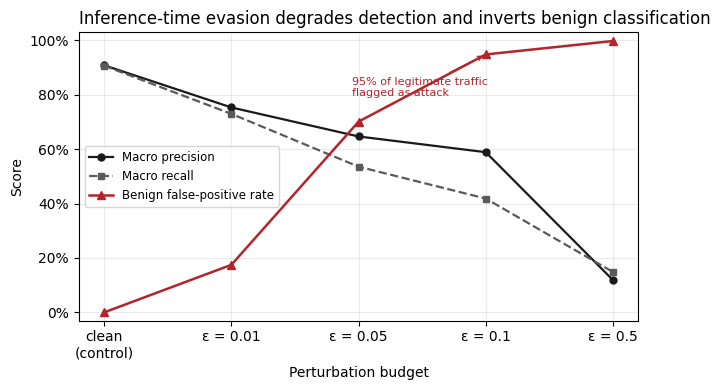

wrote Figure27_RQ2_evasion.png and Figures/data/rq2_results.json


In [19]:
ORDER = [name for name, _ in EPSILONS]
eps_list = [0.0, 0.01, 0.05, 0.10, 0.50]
prec = [res[n]["prec"] for n in ORDER]
rec  = [res[n]["rec"]  for n in ORDER]
fpr  = [res[n]["fpr"]  for n in ORDER]
print("benign FPR by condition:", [round(v, 4) for v in fpr], " (expect 0.0000 -> ~0.9981)")
INK, MID, RED = "#1a1a1a", "#5a5a5a", "#b3242b"
x = np.arange(len(ORDER))
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(x, prec, "o-",  ms=5,   lw=1.6, color=INK, label="Macro precision")
ax.plot(x, rec,  "s--", ms=5,   lw=1.6, color=MID, label="Macro recall")
ax.plot(x, fpr,  "^-",  ms=5.5, lw=1.8, color=RED, label="Benign false-positive rate")
ax.set_xticks(x)
ax.set_xticklabels(["clean\n(control)"] + [f"ε = {e:g}" for e in eps_list[1:]])
ax.set_ylim(-0.03, 1.03)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylabel("Score"); ax.set_xlabel("Perturbation budget")
ax.set_title("Inference-time evasion degrades detection and inverts benign classification", loc="left")
ax.annotate("95% of legitimate traffic\nflagged as attack", xy=(3, fpr[3]),
            xytext=(-96, -30), textcoords="offset points", fontsize=8, color=RED,
            arrowprops=dict(arrowstyle="->", lw=.9, color=RED))
ax.legend(loc="center left", fontsize=8.5); ax.grid(alpha=.25)
fig.tight_layout()
os.makedirs("Figures", exist_ok=True)
fig.savefig("Figures/Figure27_RQ2_evasion.png", dpi=300, bbox_inches="tight")
plt.show()
os.makedirs("Figures/data", exist_ok=True)
json.dump({"epsilons": eps_list, "precision": prec, "recall": rec, "fpr": fpr},
          open("Figures/data/rq2_results.json", "w"), indent=2)
print("wrote Figure27_RQ2_evasion.png and Figures/data/rq2_results.json")